> Qualitative (GradCam) and Quantative (overlap) analysis for SWIN based model including Auxiliary head, Image only baseline, Cross attention Fusion and Concat Fusion

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [ ]:


import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.gradcam import run_gradcam_quantitative_analysis, plot_gradcam_simple


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
main_folder = "../.."
img_folder = os.path.join(main_folder, "data", "train")

BACKBONE = "swin_large_patch4_window12_384"
IMG_SIZE = 384
SWIN_GRID = (12, 12)

In [5]:
# Baseline
BASELINE_DIR = os.path.join(
    main_folder, "outputs", "extra",
    "exp3_swin_384_strong_MSE_MLPHead",
)

# BCE aux models for Blur, Eyes, Face
AUX_MODEL_CONFIG = {
    "blur": {
        "dir": os.path.join(
            main_folder, "outputs", "extra",
            "exp17_swin_384_strong_MSELoss_Blur_Aux_StrongHead",
        ),
        "binary_name": "Blur",
        "is_bce": True,
        "display_name": "Blur-aux ",
    },
    "eyes": {
        "dir": os.path.join(
            main_folder, "outputs", "extra",
            "exp17_swin_384_strong_MSELoss_Eyes_Aux_StrongHead",
        ),
        "binary_name": "Eyes",
        "is_bce": True,
        "display_name": "Eyes-aux ",
    },
    "face": {
        "dir": os.path.join(
            main_folder, "outputs", "extra",
            "exp17_swin_384_strong_MSELoss_Face_Aux_StrongHead",
        ),
        "binary_name": "Face",
        "is_bce": True,
        "display_name": "Face-aux ",
    },
}

FUSION_MODEL_CONFIG = {
    "concat": {
        "dir": os.path.join(
            main_folder, "outputs", "extra",
            "exp5_SwinT_StrongAug_MLPHead_mse",
        ),
        "display_name": "Concat fusion",
        "tab_hidden": 64,
        "fusion_hidden": 256,
        "head_type": "mlp",
        "freeze_backbone": False,
        "tab_encoder_capacity": "small",
    },
    "crossattn": {
        "dir": os.path.join(
            main_folder, "outputs", "extra",
            "exp13_swin_cross_attn_mse_loss_single_block_tab_transformer",
        ),
        "display_name": "Cross-attn fusion",
        "tab_hidden": 64,
        "num_heads": 8,
        "head_hidden": 256,
        "dropout": 0.1,
        "freeze_backbone": False,
        "tab_encoder_capacity": "tab_transformer",
        "query_mode": "tab_queries_image",
        "num_cross_attn_blocks": 1,
        "use_global_image_feature": True,
    },
}

DISPLAY_NAMES = {
    "main": "Baseline",
    **{k: v["display_name"] for k, v in AUX_MODEL_CONFIG.items()},
    **{k: v["display_name"] for k, v in FUSION_MODEL_CONFIG.items()},
}

In [6]:
df = pd.read_csv(os.path.join(main_folder, "data", "train_with_visibility_test.csv"))
TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]
tab_cols_fusion = [
    "Subject Focus","Eyes","Face","Near", "Action","Accessory","Group","Collage","Human","Occlusion","Info","Blur",
]
out_extra = os.path.join(main_folder, "outputs", "extra","exp18_aux_heads_metadata_weightedBCELoss")
os.makedirs(out_extra, exist_ok=True)

### 1A , Aux head of metadata with Aux head BCE loss (not weighted BCE Loss)

/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


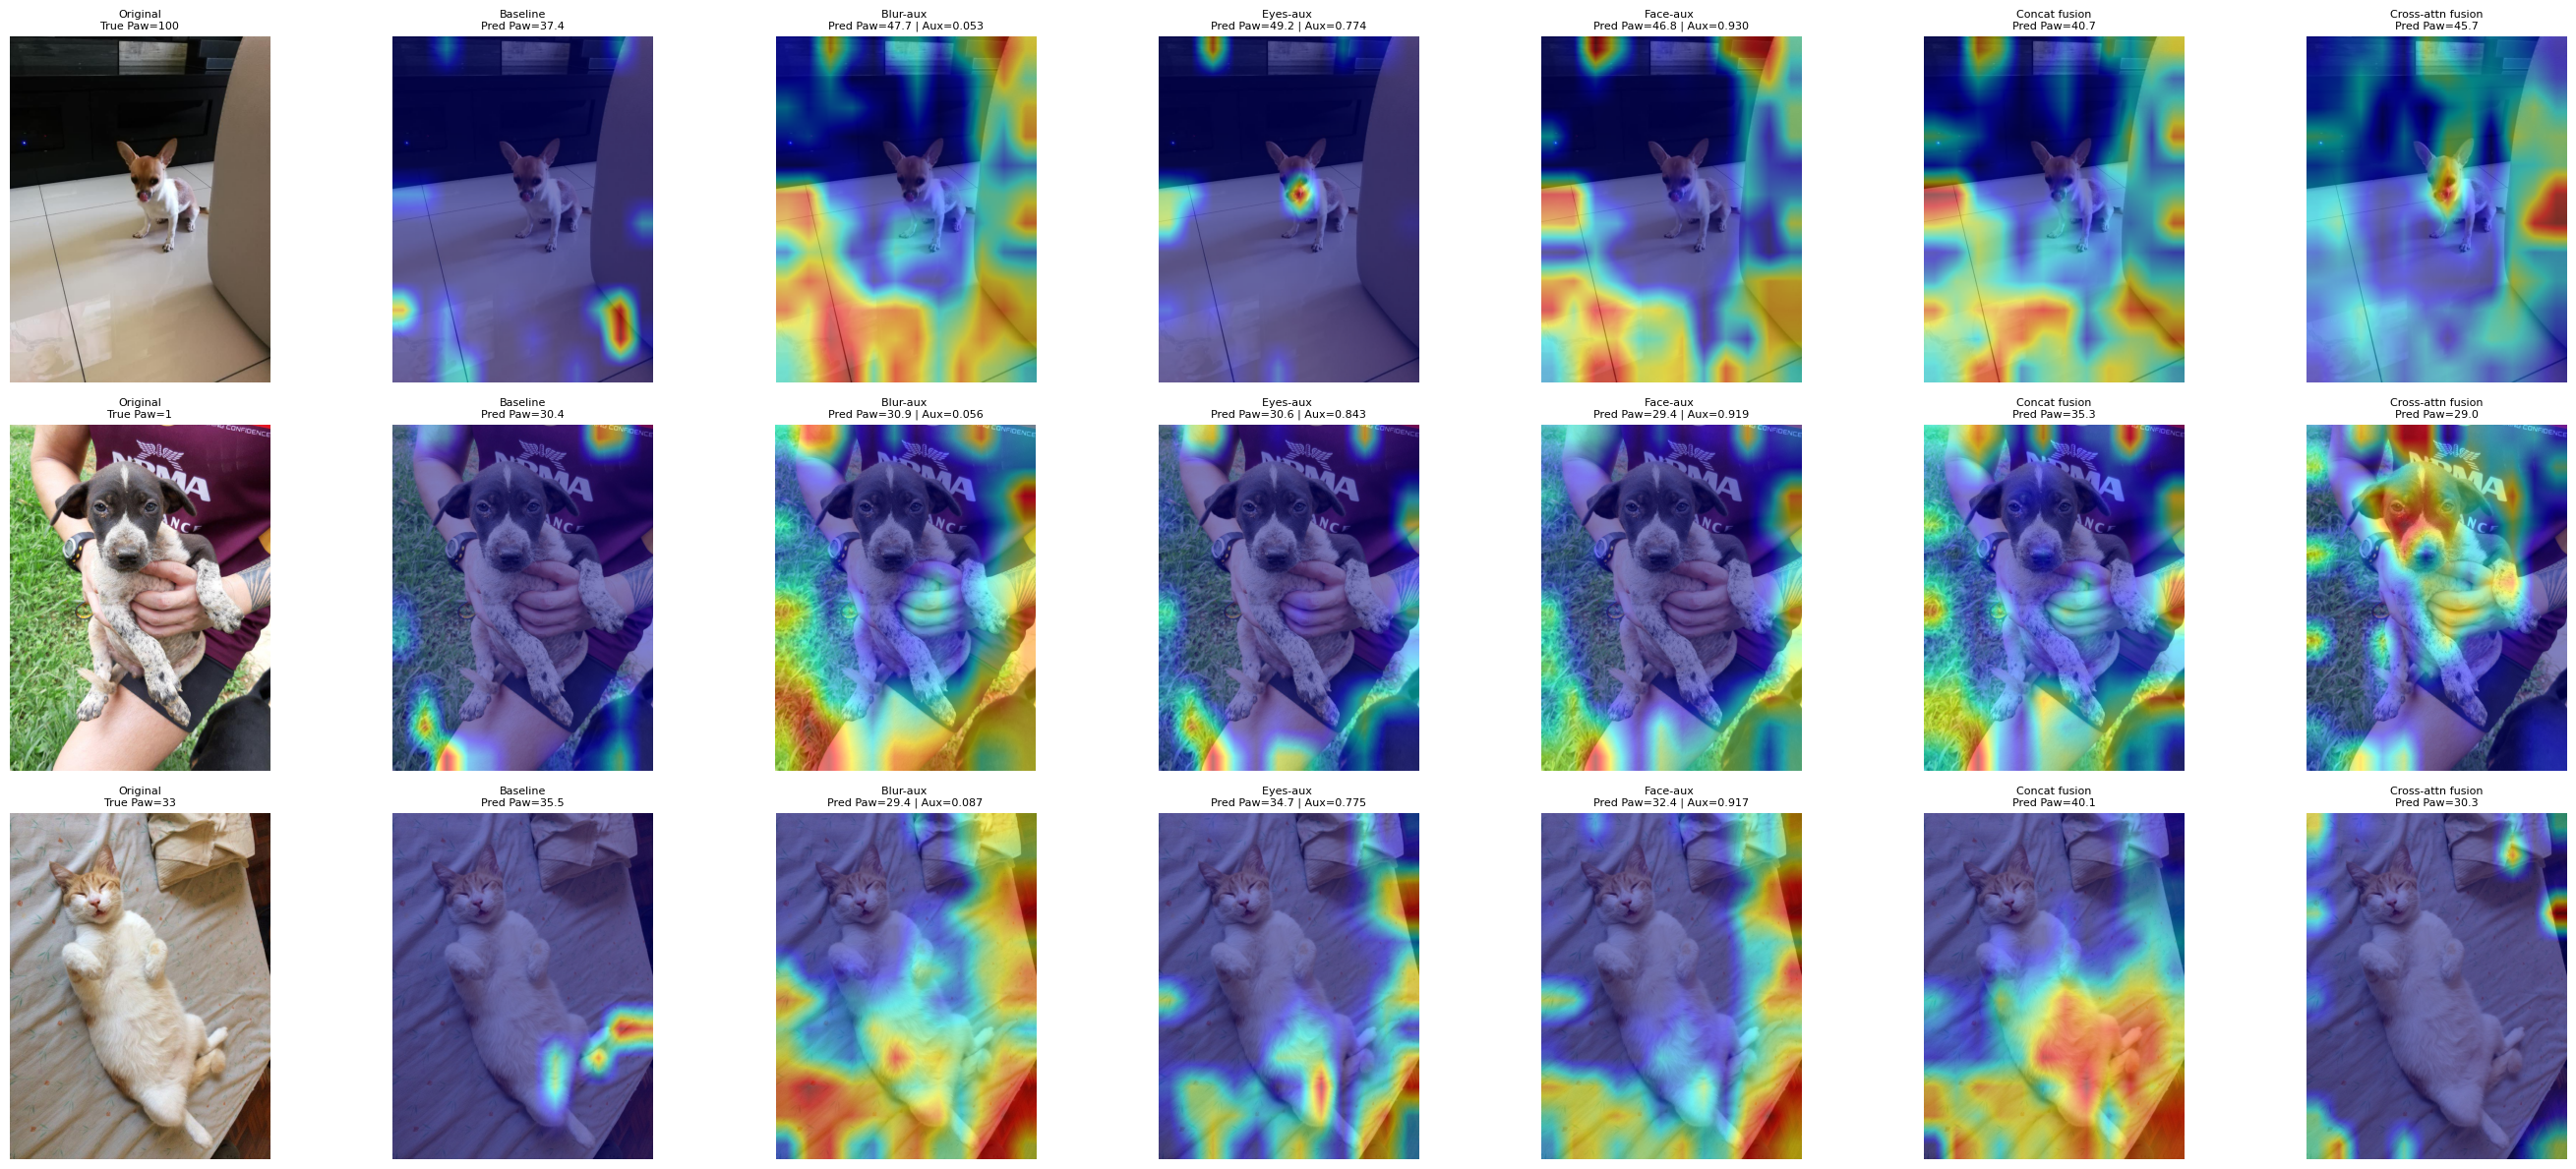

In [7]:
plot_gradcam_simple(
    df=df,
    img_folder=img_folder,
    fold=1,
    model_names=["main", "blur", "eyes", "face", "concat", "crossattn"],
    save_path=os.path.join(
        main_folder, "outputs", "extra", "exp18_gradcam_qualitative.png"
    ),
    device=device,
    backbone=BACKBONE,
    img_size=IMG_SIZE,
    baseline_dir=BASELINE_DIR,
    aux_model_config=AUX_MODEL_CONFIG,
    fusion_model_config=FUSION_MODEL_CONFIG,
    display_names=DISPLAY_NAMES,
    n_high=1,
    n_mid=1,
    n_low=1,
    selection_mode="pawpularity",
    oof_df=None,
    tab_cols=tab_cols_fusion,
    grid_size=SWIN_GRID,
    aug_type="strong",
    pseudo_aux_config=None,
)

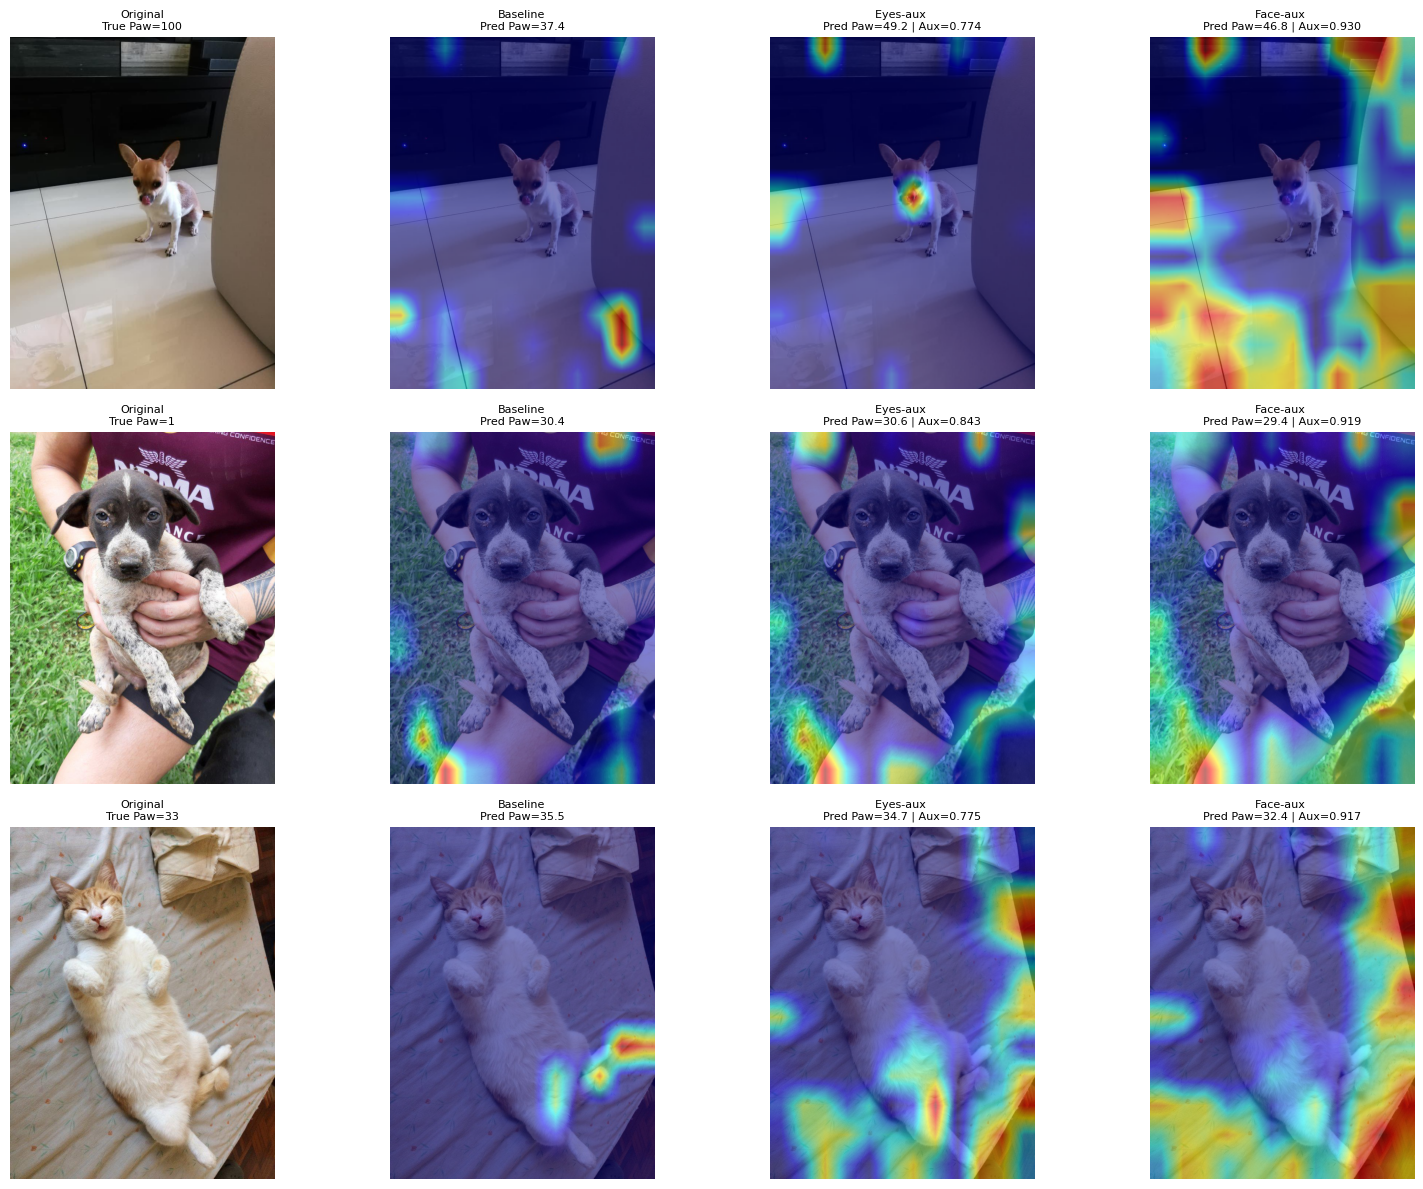

In [8]:
plot_gradcam_simple(
    df=df,
    img_folder=img_folder,
    fold=1,
    model_names=["main", "eyes", "face"],
    save_path=os.path.join(main_folder, "outputs", "extra", "exp18_gradcam_aux.png"),
    device=device,
    backbone=BACKBONE,
    img_size=IMG_SIZE,
    baseline_dir=BASELINE_DIR,
    aux_model_config=AUX_MODEL_CONFIG,
    fusion_model_config=FUSION_MODEL_CONFIG,
    display_names=DISPLAY_NAMES,
    n_high=1,
    n_mid=1,
    n_low=1,
    selection_mode="pawpularity",
    oof_df=None,
    tab_cols=None,
    grid_size=SWIN_GRID,
    aug_type="strong",
    pseudo_aux_config=None,
)

In [9]:
folds = [1, 2, 3, 4, 5]
model_names = ["main", "blur", "eyes", "face", "concat", "crossattn"]

img_df, summary_df, corr_df = run_gradcam_quantitative_analysis(
    df=df,
    img_folder=img_folder,
    folds=folds,
    model_names=model_names,
    device=device,
    backbone=BACKBONE,
    img_size=IMG_SIZE,
    baseline_dir=BASELINE_DIR,
    aux_model_config=AUX_MODEL_CONFIG,
    fusion_model_config=FUSION_MODEL_CONFIG,
    tab_cols=tab_cols_fusion,
    grid_size=SWIN_GRID,
    aug_type="strong",
    pseudo_aux_config=None,
    yolo_conf_threshold=0.3,
)


display(summary_df)
display(corr_df)

/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/ghias/miniconda3/envs/

,model_name,mean_cam_pet_overlap,mean_cam_face_overlap
0,blur,0.104634,0.020067
1,concat,0.096348,0.020206
2,crossattn,0.097971,0.055035
3,eyes,0.074294,0.021407
4,face,0.098383,0.022152
5,main,0.077046,0.016921


,model_name,pearson_cam_pet_vs_abs_err,spearman_cam_pet_vs_abs_err,pearson_cam_face_vs_abs_err,spearman_cam_face_vs_abs_err
0,blur,0.070723,0.069047,0.152804,0.130828
1,concat,0.129584,0.106903,0.182890,0.175618
2,crossattn,0.241560,0.221573,0.207985,0.184173
3,eyes,0.141593,0.086563,0.185431,0.162852
4,face,0.129538,0.122143,0.152126,0.147357
5,main,0.144890,0.087464,0.186133,0.158515


In [ ]:
# High vs low overlap error comparison BCE
from src.gradcam import compute_overlap_error_quartile_analysis


quartile_df = compute_overlap_error_quartile_analysis(
    img_df=img_df,
    model_names=model_names,
    display_names=DISPLAY_NAMES,
    overlap_col="cam_pet_overlap",
    error_col="abs_error",
)
print("\n=== High vs Low CAM-pet Overlap: Mean Error Comparison (BCE) ===")
print(quartile_df[[
    "display_name",
    "low_overlap_threshold",    
    "high_overlap_threshold",
    "low_overlap_mean_overlap",
    "high_overlap_mean_overlap",
    "pearson_low_group",
    "spearman_low_group",
    "low_overlap_mean_error",
    "high_overlap_mean_error",
    "difference"
]].to_string(index=False))

quartile_df.to_csv(
    os.path.join(out_extra, "exp18_bce_overlap_quartile_analysis.csv"),
    index=False
)


=== High vs Low CAM-pet Overlap: Mean Error Comparison (BCE) ===
     display_name  low_overlap_threshold  high_overlap_threshold  low_overlap_mean_overlap  high_overlap_mean_overlap  pearson_low_group  spearman_low_group  low_overlap_mean_error  high_overlap_mean_error  difference
         Baseline                  0.005                   0.099                    0.0006                     0.2300             -0.037              -0.057                   11.28                    14.61        3.33
        Blur-aux                   0.007                   0.142                    0.0011                     0.3095              0.029               0.046                   11.49                    13.98        2.49
        Eyes-aux                   0.005                   0.098                    0.0007                     0.2161             -0.046              -0.039                   11.08                    14.53        3.45
        Face-aux                   0.002                   0.1

### 1B , Aux head of metadata with BCE weighted loss 

In [10]:
#  weighted BCE config — separate from old AUX_MODEL_CONFIG
AUX_MODEL_CONFIG_WBCE = {
    "blur_wbce": {
        "dir": os.path.join(
            main_folder, "outputs", "extra",
            "exp18_aux_heads_metadata_weightedBCELoss",
            "exp18_swin_384_strong_MSELoss_Blur_AuxBCEWeightedLoss_StrongHead",
        ),
        "binary_name": "Blur",
        "is_bce": True,
        "display_name": "Blur-aux (wBCE)",
    },
    "eyes_wbce": {
        "dir": os.path.join(
            main_folder, "outputs", "extra",
            "exp18_aux_heads_metadata_weightedBCELoss",
            "exp18_swin_384_strong_MSELoss_Eyes_AuxBCEWeightedLoss_StrongHead",
        ),
        "binary_name": "Eyes",
        "is_bce": True,
        "display_name": "Eyes-aux (wBCE)",
    },
    "face_wbce": {
        "dir": os.path.join(
            main_folder, "outputs", "extra",
            "exp18_aux_heads_metadata_weightedBCELoss",
            "exp18_swin_384_strong_MSELoss_Face_AuxBCEWeightedLoss_StrongHead",
        ),
        "binary_name": "Face",
        "is_bce": True,
        "display_name": "Face-aux (wBCE)",
    },
}

#  DISPLAY_NAMES 
DISPLAY_NAMES.update({k: v["display_name"] for k, v in AUX_MODEL_CONFIG_WBCE.items()})


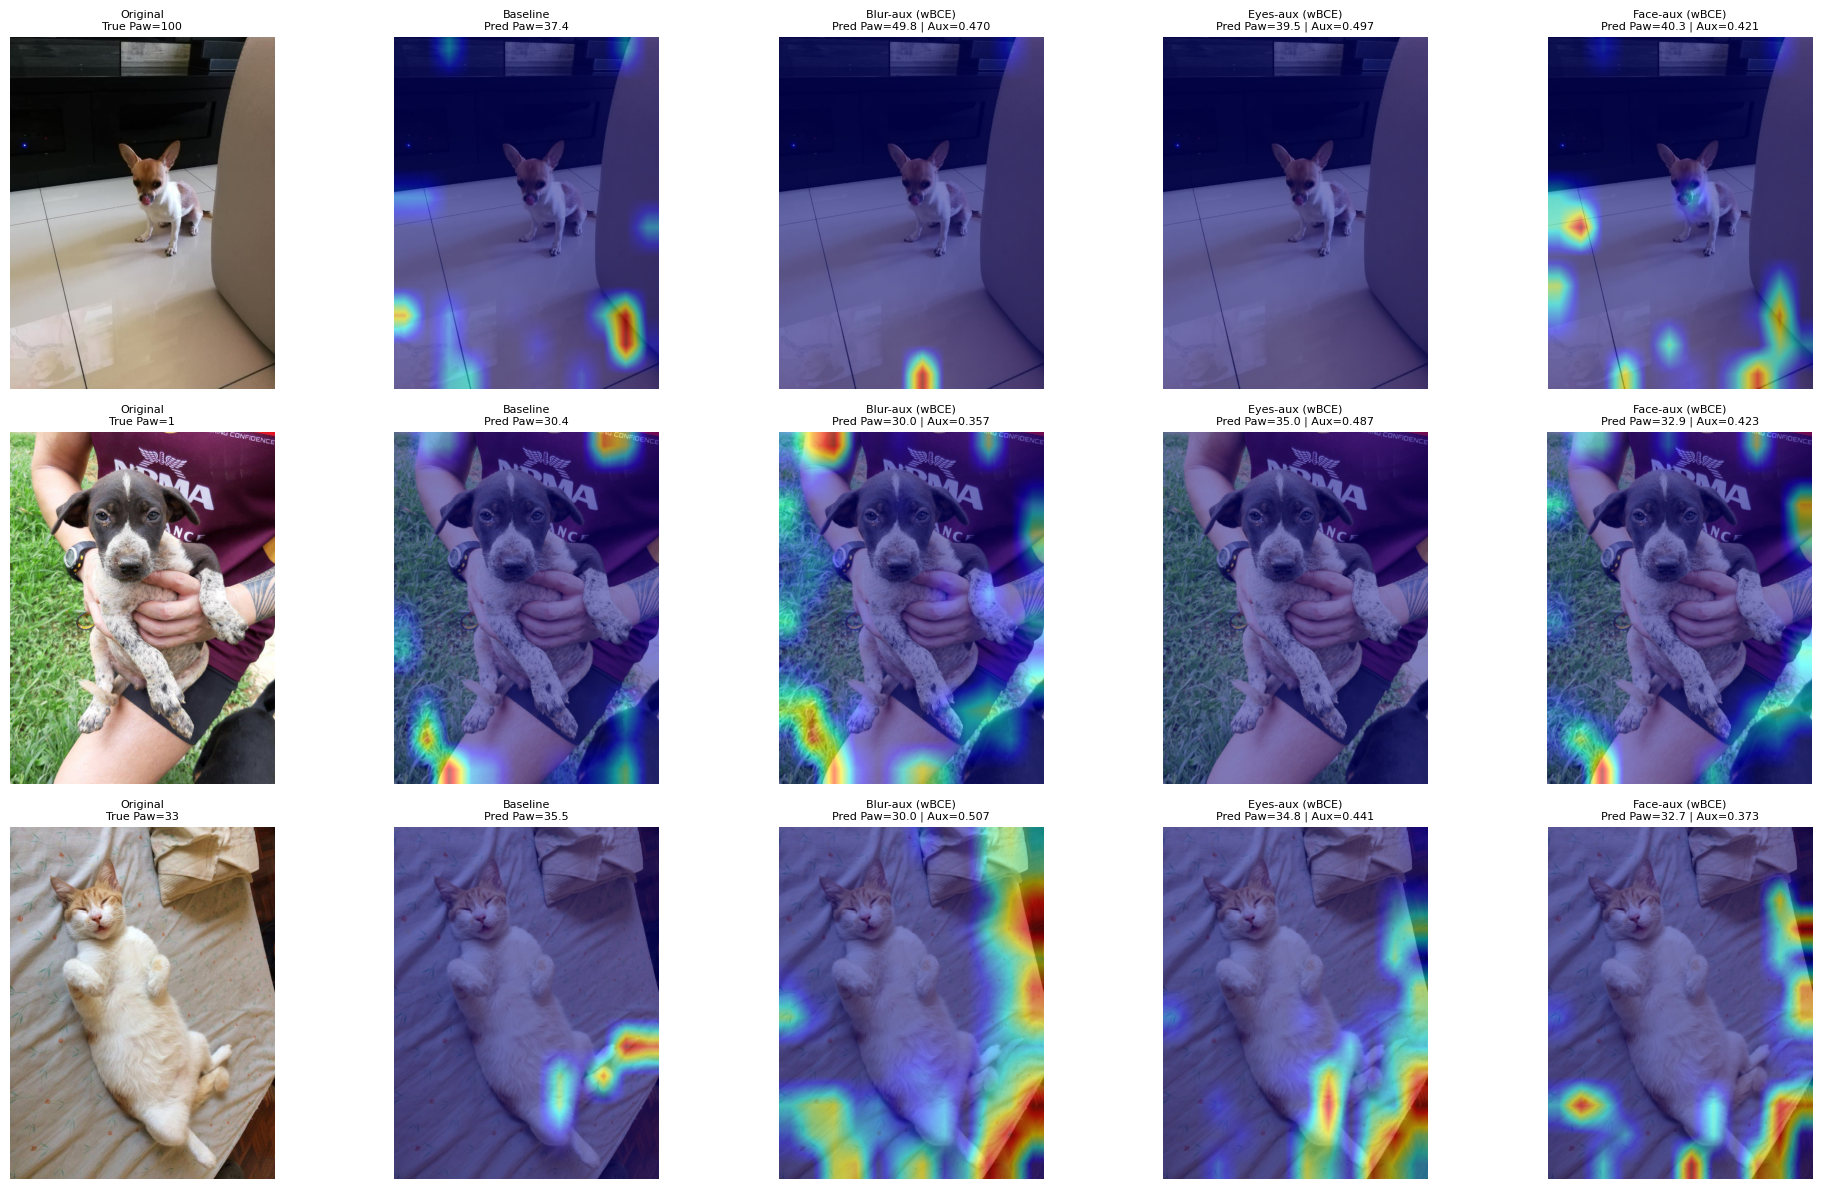

In [11]:
plot_gradcam_simple(
    df=df,
    img_folder=img_folder,
    fold=1,
    model_names=["main", "blur_wbce", "eyes_wbce", "face_wbce"],  
    save_path=os.path.join(main_folder, "outputs", "extra", "exp18_gradcam_wbce_aux.png"),  
    device=device,
    backbone=BACKBONE,
    img_size=IMG_SIZE,
    baseline_dir=BASELINE_DIR,
    aux_model_config=AUX_MODEL_CONFIG_WBCE,  
    fusion_model_config=FUSION_MODEL_CONFIG,
    display_names=DISPLAY_NAMES,
    n_high=1,
    n_mid=1,
    n_low=1,
    selection_mode="pawpularity",
    oof_df=None,
    tab_cols=None,
    grid_size=SWIN_GRID,
    aug_type="strong",
    pseudo_aux_config=None,
)

In [12]:
model_names_wbce = ["main", "blur_wbce", "eyes_wbce", "face_wbce", "concat", "crossattn"]  

img_df_wbce, summary_df_wbce, corr_df_wbce = run_gradcam_quantitative_analysis(  
    df=df,
    img_folder=img_folder,
    folds=[1, 2, 3, 4, 5],
    model_names=model_names_wbce,  
    device=device,
    backbone=BACKBONE,
    img_size=IMG_SIZE,
    baseline_dir=BASELINE_DIR,
    aux_model_config=AUX_MODEL_CONFIG_WBCE,  
    fusion_model_config=FUSION_MODEL_CONFIG,
    tab_cols=tab_cols_fusion,
    grid_size=SWIN_GRID,
    aug_type="strong",
    pseudo_aux_config=None,
    yolo_conf_threshold=0.3,
)

display(summary_df_wbce)   
display(corr_df_wbce)      

/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/ghias/miniconda3/envs/

,model_name,mean_cam_pet_overlap,mean_cam_face_overlap
0,blur_wbce,0.074846,0.018915
1,concat,0.096348,0.020206
2,crossattn,0.097971,0.055035
3,eyes_wbce,0.085430,0.023156
4,face_wbce,0.100831,0.025056
5,main,0.077046,0.016921


,model_name,pearson_cam_pet_vs_abs_err,spearman_cam_pet_vs_abs_err,pearson_cam_face_vs_abs_err,spearman_cam_face_vs_abs_err
0,blur_wbce,0.138178,0.117666,0.168247,0.165264
1,concat,0.129584,0.106903,0.182890,0.175618
2,crossattn,0.241560,0.221573,0.207985,0.184173
3,eyes_wbce,0.123753,0.120056,0.176257,0.196181
4,face_wbce,0.050922,0.058164,0.133818,0.119086
5,main,0.144890,0.087464,0.186133,0.158515


In [27]:
# High vs low overlap error comparison — weighted BCE
quartile_df_wbce = compute_overlap_error_quartile_analysis(
    img_df=img_df_wbce,
    model_names=model_names_wbce,
    display_names=DISPLAY_NAMES,
    overlap_col="cam_pet_overlap",
    error_col="abs_error",
)
print("\n=== High vs Low CAM-pet Overlap: Mean Error Comparison (wBCE) ===")
print(quartile_df_wbce[[
    "display_name",
    "low_overlap_threshold",
    "high_overlap_threshold",
    "low_overlap_mean_overlap",
    "high_overlap_mean_overlap",
    "pearson_low_group",
    "spearman_low_group",
    "pearson_high_group",
    "spearman_high_group",
    "low_overlap_mean_error",
    "high_overlap_mean_error",
    "difference"
]].to_string(index=False))

quartile_df_wbce.to_csv(
    os.path.join(out_extra, "exp18_wbce_overlap_quartile_analysis.csv"),
    index=False
)


=== High vs Low CAM-pet Overlap: Mean Error Comparison (wBCE) ===
     display_name  low_overlap_threshold  high_overlap_threshold  low_overlap_mean_overlap  high_overlap_mean_overlap  pearson_low_group  spearman_low_group  pearson_high_group  spearman_high_group  low_overlap_mean_error  high_overlap_mean_error  difference
         Baseline                  0.005                   0.099                    0.0006                     0.2300             -0.037              -0.057               0.210                0.199                   11.28                    14.61        3.33
  Blur-aux (wBCE)                  0.002                   0.082                    0.0002                     0.2360              0.011               0.013               0.171                0.170                   11.10                    14.87        3.77
  Eyes-aux (wBCE)                  0.002                   0.079                    0.0001                     0.2857             -0.047              -0.036

### 2 Pseudolabel based aux data head 

In [15]:
PSEUDO_AUX_CONFIG = {
    "brisque": {
        "dir": os.path.join(
            main_folder, "outputs", "extra",
            "exp15_swin_384_strong_MSE_aux_brisque_normalized_fixNormLeakage_brisque_strongHead",
        ),
        "aux_name": "brisque",
        "use_saliency": False,
        "head_type": "mlp",
        "display_name": "BRISQUE-aux",
    },
    "visibility_ratio": {
        "dir": os.path.join(
            main_folder, "outputs", "extra",
            "exp15_swin_384_strong_MSE_aux_visibility_normalized_MLP_Head",
        ),
        "aux_name": "visibility_ratio",
        "use_saliency": False,
        "head_type": "mlp",
        "display_name": "Visibility-aux",
    },
    "saliency": {
        "dir": os.path.join(
            main_folder, "outputs", "extra",
            "exp16_swin_384_strong_MSELoss_saliency_strongHead",
        ),
        "aux_name": None,
        "use_saliency": True,
        "head_type": "mlp",
        "display_name": "Saliency",
    },
}

DISPLAY_NAMES.update({k: v["display_name"] for k, v in PSEUDO_AUX_CONFIG.items()})

pseudo_models = ["main", "brisque", "visibility_ratio", "saliency"]

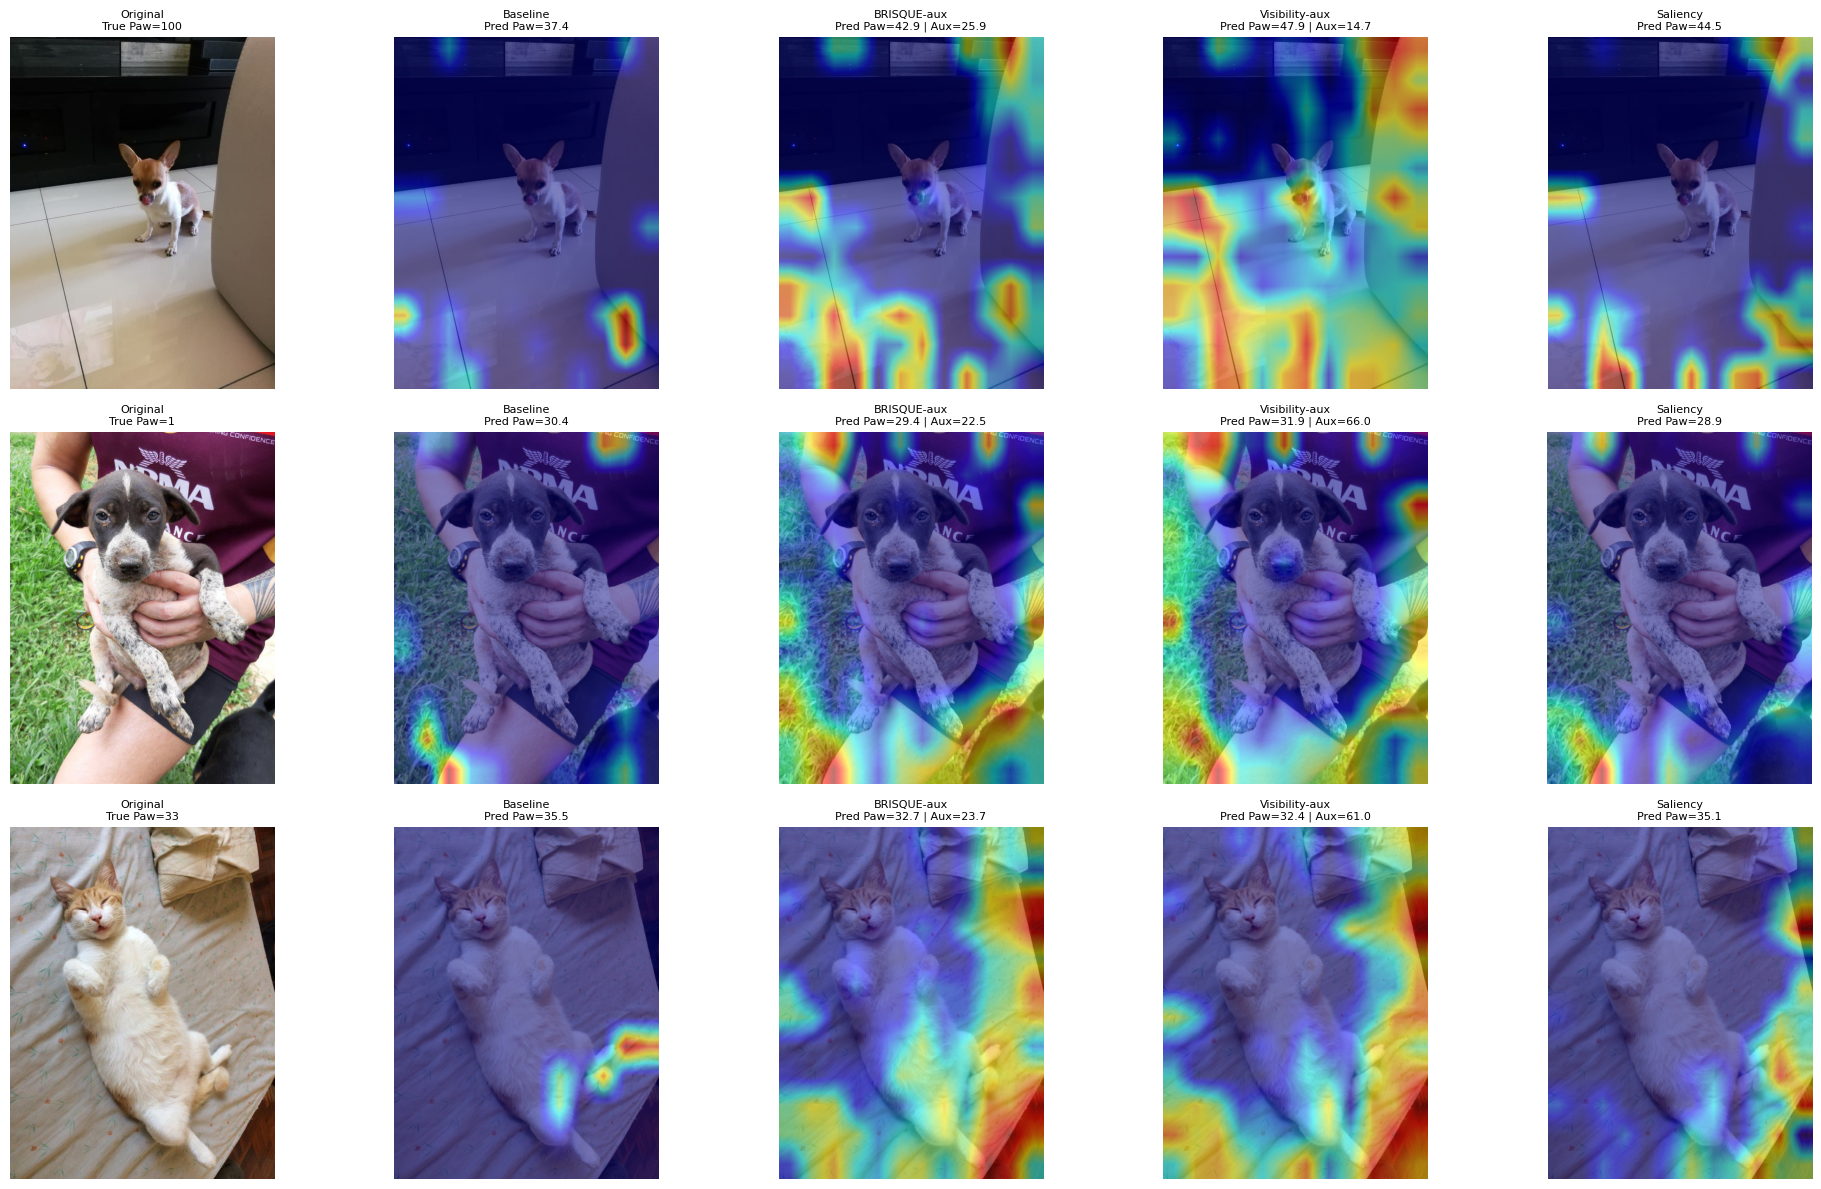

In [ ]:
plot_gradcam_simple(
    df=df,
    img_folder=img_folder,
    fold=1,
    model_names=["main", "brisque", "visibility_ratio", "saliency"],
    save_path=os.path.join(main_folder, "outputs", "extra", "exp18_gradcam_pseudo.png"),
    device=device,
    backbone=BACKBONE,
    img_size=IMG_SIZE,
    baseline_dir=BASELINE_DIR,
    aux_model_config=AUX_MODEL_CONFIG,         
    fusion_model_config=FUSION_MODEL_CONFIG,  
    display_names=DISPLAY_NAMES,
    n_high=1,
    n_mid=1,
    n_low=1,
    selection_mode="pawpularity",
    oof_df=None,
    tab_cols=None,                             
    grid_size=SWIN_GRID,
    aug_type="strong",
    pseudo_aux_config=PSEUDO_AUX_CONFIG,       
)

In [ ]:


img_df_pseudo, summary_df_pseudo, corr_df_pseudo = run_gradcam_quantitative_analysis(
    df=df,
    img_folder=img_folder,
    folds=[1, 2, 3, 4, 5],
    model_names=pseudo_models,
    device=device,
    backbone=BACKBONE,
    img_size=IMG_SIZE,
    baseline_dir=BASELINE_DIR,
    aux_model_config=AUX_MODEL_CONFIG,    
    fusion_model_config=FUSION_MODEL_CONFIG,
    tab_cols=None,                        
    grid_size=SWIN_GRID,
    aug_type="strong",
    pseudo_aux_config=PSEUDO_AUX_CONFIG,  # 
    yolo_conf_threshold=0.3,
)
display(summary_df_pseudo)
display(corr_df_pseudo)

,model_name,mean_cam_pet_overlap,mean_cam_face_overlap
0,brisque,0.076245,0.018465
1,main,0.077046,0.016921
2,saliency,0.079711,0.016952
3,visibility_ratio,0.083202,0.020015


,model_name,pearson_cam_pet_vs_abs_err,spearman_cam_pet_vs_abs_err,pearson_cam_face_vs_abs_err,spearman_cam_face_vs_abs_err
0,brisque,0.108634,0.076170,0.158536,0.132501
1,main,0.144890,0.087464,0.186133,0.158515
2,saliency,0.153305,0.097093,0.188055,0.177853
3,visibility_ratio,0.135695,0.106516,0.196485,0.171073


In [32]:
quartile_df_pseudo = compute_overlap_error_quartile_analysis(
    img_df=img_df_pseudo,
    model_names=pseudo_models,
    display_names=DISPLAY_NAMES,
    overlap_col="cam_pet_overlap",
    error_col="abs_error",
)

print("\n=== High vs Low CAM-pet Overlap: Mean Error Comparison (Pseudo-label) ===")
print(quartile_df_pseudo[[
    "display_name",
    "low_overlap_threshold",
    "high_overlap_threshold",
    "low_overlap_mean_overlap",
    "high_overlap_mean_overlap",
    "pearson_low_group",
    "spearman_low_group",
    "pearson_high_group",      
    "spearman_high_group",
    "low_overlap_mean_error",
    "high_overlap_mean_error",
    "difference"
]].to_string(index=False))

quartile_df_pseudo.to_csv(
    os.path.join(out_extra, "exp18_pseudo_overlap_quartile_analysis.csv"),
    index=False
)


=== High vs Low CAM-pet Overlap: Mean Error Comparison (Pseudo-label) ===
  display_name  low_overlap_threshold  high_overlap_threshold  low_overlap_mean_overlap  high_overlap_mean_overlap  pearson_low_group  spearman_low_group  pearson_high_group  spearman_high_group  low_overlap_mean_error  high_overlap_mean_error  difference
      Baseline                  0.005                   0.099                    0.0006                     0.2300             -0.037              -0.057               0.210                0.199                   11.28                    14.61        3.33
   BRISQUE-aux                  0.002                   0.091                    0.0002                     0.2425              0.036               0.051               0.163                0.145                   11.55                    14.05        2.50
Visibility-aux                  0.009                   0.113                    0.0018                     0.2307              0.059               0.053    